# WR Best Final Models - Consolidated Notebook

Finalni notebook koji konsoliduje najbolje verzije svih modela iz WR pipeline-a.
Svi hiperparametri su fiksirani iz ranijih eksperimenata (Optuna, ablacije).

## Modeli u notebook-u

Baseline ML:
1. RandomForest
2. XGBoost
3. LightGBM

MLP:

4. MLP Hybrid (Huber loss + GaussianNoise)
5. MLP B Varijanta
6. MLP Quantile q50 (pinball loss)

Sekvencijalni:

7. LSTM 
8. GRU 

Ensemble:

9. Optimized weighted ensemble 


---
## 1. Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, json, time, random
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization, GaussianNoise,
    LSTM, GRU, Masking, Concatenate,
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

PROJECT_ROOT = Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'fully combined' / 'wr_all_weeks.csv'
RESULTS_DIR = PROJECT_ROOT / 'results'
if not DATA_PATH.exists():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        candidate_data_path = candidate / 'data' / 'fully combined' / 'wr_all_weeks.csv'
        if candidate_data_path.exists():
            PROJECT_ROOT = candidate
            DATA_PATH = candidate_data_path
            RESULTS_DIR = PROJECT_ROOT / 'results'
            break
    else:
        raise FileNotFoundError(f'Could not find wr_all_weeks.csv from {Path.cwd()}')

print(f'TensorFlow {tf.__version__}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Data path: {DATA_PATH}')

TensorFlow 2.21.0
Project root: C:\Users\Korisnik\Documents\GitHub\Analiza-i-Obrada
Data path: C:\Users\Korisnik\Documents\GitHub\Analiza-i-Obrada\data\fully combined\wr_all_weeks.csv


---
## 2. Feature Engineering (tabular + sequence)

Ista priprema kao u `WR_Ensemble_Final` + dodatni raw cols za sekvencne modele.


In [2]:
df = pd.read_csv(DATA_PATH)
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

work_df = df.copy()

# Rename win-prob columns for safe identifiers
wp_rename_map = {
    'yards_wp_<25':       'yards_wp_less_than_25',
    'yards_wp_>75':       'yards_wp_greater_than_75',
    'receptions_wp_<25':  'receptions_wp_less_than_25',
    'receptions_wp_>75':  'receptions_wp_greater_than_75',
    'targets_wp_<25':     'targets_wp_less_than_25',
    'targets_wp_>75':     'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

# Team detection
work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan,
    ),
)
prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna()
    & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (prev_season.notna() & (work_df['season'] != prev_season)).astype(int)

work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

# Career averages from last season
season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(avg_yards=('receiving_yards', 'mean'),
         avg_target_share=('target_share', 'mean'),
         avg_epa=('epa', 'mean'),
         avg_air_yard_share=('air_yard_share', 'mean'),
         avg_catch_rate=('catch_rate', 'mean'),
         games_played=('game_id', 'count'))
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [f'{c}_last_season' for c in
               ['avg_yards', 'avg_target_share', 'avg_epa',
                'avg_air_yard_share', 'avg_catch_rate', 'games_played']]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)

print(f'Base dataset: {work_df.shape}')

Base dataset: (46115, 110)


In [3]:
# Rolling / lag / momentum / interaction features (produce top-40 space)
rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]
available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []
for col in available_roll_cols:
    work_df[f'{col}_lag1']  = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])

# Momentum features (lag1 - roll5)
momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col, roll5_col = f'{col}_lag1', f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

# Interaction features
interaction_cols = []
if 'target_share_lag1' in work_df.columns:
    work_df['target_volume_interaction'] = (
        work_df['target_share_lag1'] * work_df['pregame_total']
    )
    interaction_cols.append('target_volume_interaction')
if 'air_yard_share_lag1' in work_df.columns and 'team_pass_attempts_lag1' in work_df.columns:
    work_df['air_yards_expected'] = (
        work_df['air_yard_share_lag1'] * work_df['team_pass_attempts_lag1']
    )
    interaction_cols.append('air_yards_expected')
if 'catch_rate_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['expected_receptions'] = (
        work_df['catch_rate_lag1'] * work_df['targets_lag1']
    )
    interaction_cols.append('expected_receptions')
if 'epa_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['epa_per_target'] = (
        work_df['epa_lag1'] / work_df['targets_lag1'].replace(0, np.nan)
    ).fillna(0)
    interaction_cols.append('epa_per_target')

pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f',
    'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear',
    'season', 'week', 'team_changed', 'is_new_season',
]
all_feature_columns = (
    pregame_features + career_cols + derived_cols + momentum_cols + interaction_cols
)

model_df = work_df.copy()
lag1_all = [c for c in all_feature_columns if c.endswith('_lag1')]
model_df = model_df.loc[~model_df[lag1_all].isna().all(axis=1)].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df[all_feature_columns] = model_df[all_feature_columns].fillna(0)
model_df['receiving_yards_sqrt'] = np.sqrt(model_df['receiving_yards'].clip(lower=0))

print(f'Modeling dataset: {model_df.shape}')
print(f'Tabular features engineered: {len(all_feature_columns)}')


Modeling dataset: (44396, 275)
Tabular features engineered: 184


---
## 3. Tabular Split + Feature setovi


In [4]:
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

train_df = model_df[model_df['season'].isin(train_seasons)].copy()
val_df   = model_df[model_df['season'].isin(val_seasons)].copy()
test_df  = model_df[model_df['season'].isin(test_seasons)].copy()

y_train_sqrt = train_df['receiving_yards_sqrt'].values
y_val_sqrt   = val_df['receiving_yards_sqrt'].values
y_test_sqrt  = test_df['receiving_yards_sqrt'].values
y_train_orig = train_df['receiving_yards'].values
y_val_orig   = val_df['receiving_yards'].values
y_test_orig  = test_df['receiving_yards'].values

with open(PROJECT_ROOT / 'results' / 'selected_features_top40.json', 'r') as f:
    selected_features = json.load(f)['selected_features']

missing = [f for f in selected_features if f not in train_df.columns]
if missing:
    raise ValueError(f'Missing top-40 features: {missing}')

# Top-40 tabular space (used by RF/LGB/MLP and ensemble members)
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[selected_features].values)
X_val   = scaler.transform(val_df[selected_features].values)
X_test  = scaler.transform(test_df[selected_features].values)

# Full 184-feature tabular space (used by XGBoost)
scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(train_df[all_feature_columns].values)
X_val_all   = scaler_all.transform(val_df[all_feature_columns].values)
X_test_all  = scaler_all.transform(test_df[all_feature_columns].values)

mean_y_train = np.mean(np.clip(y_train_orig, 0, None))
sw_train = 1.0 + 0.6 * np.sqrt(np.clip(y_train_orig, 0, None) / mean_y_train)

print(f'Train top-40: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Train all-184: {X_train_all.shape}  Val: {X_val_all.shape}  Test: {X_test_all.shape}')
print(f'Features: {X_train.shape[1]} (top-40) + {X_train_all.shape[1]} (all)')
print(f'Sample weights range: [{sw_train.min():.2f}, {sw_train.max():.2f}]')

Train top-40: (29276, 40)  Val: (8921, 40)  Test: (6199, 40)
Train all-184: (29276, 184)  Val: (8921, 184)  Test: (6199, 184)
Features: 40 (top-40) + 184 (all)
Sample weights range: [1.00, 2.87]


---
## 4. Utility Functions


In [5]:
def eval_preds(y_true_orig, y_pred_orig):
    return {
        'MAE':  float(mean_absolute_error(y_true_orig, y_pred_orig)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))),
        'R2':   float(r2_score(y_true_orig, y_pred_orig)),
    }

def sqrt_to_orig(p):
    return np.clip(p, 0, None) ** 2

# holds per-model {val, test, seconds, val_pred_orig, test_pred_orig}
results = {}

def log_result(name, val_metrics, test_metrics, seconds=None,
               val_pred=None, test_pred=None):
    results[name] = {
        'val': val_metrics, 'test': test_metrics, 'seconds': seconds,
        'val_pred': val_pred, 'test_pred': test_pred,
    }
    s = f' ({seconds:.0f}s)' if seconds is not None else ''
    print(f'{name:32}{s}  val MAE={val_metrics["MAE"]:.3f}  '
          f'test MAE={test_metrics["MAE"]:.3f}  R2={test_metrics["R2"]:.4f}')

print('Utils defined.')


Utils defined.


---
## 5. Baseline ML Models (3 modela)

Tri klasicna ML modela kao baseline 



### 5.1 RandomForest
Arhitektura: 300 stabala, max_depth=10, min_samples_leaf=4, sqrt target,
sample weights 0.6.


In [6]:
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=4,
    random_state=SEED, n_jobs=-1,
)
rf.fit(X_train, y_train_sqrt, sample_weight=sw_train)

rf_val_pred  = sqrt_to_orig(rf.predict(X_val))
rf_test_pred = sqrt_to_orig(rf.predict(X_test))
log_result('RandomForest',
           eval_preds(y_val_orig,  rf_val_pred),
           eval_preds(y_test_orig, rf_test_pred),
           val_pred=rf_val_pred, test_pred=rf_test_pred)


RandomForest                      val MAE=18.129  test MAE=17.853  R2=0.3321


### 5.2 XGBoost

Arhitektura: 300 stabala, `max_depth=4`, `learning_rate=0.05`, `subsample=0.8`,
`colsample_bytree=0.8`, L1=0.1, L2=1.0.

XGBoost se trenira na svih 184 tabular feature-a 

In [7]:
t0 = time.time()
xgb = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='rmse',
)
xgb.fit(X_train_all, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val_all, y_val_sqrt)], verbose=False)

xgb_val_pred  = sqrt_to_orig(xgb.predict(X_val_all))
xgb_test_pred = sqrt_to_orig(xgb.predict(X_test_all))
log_result('XGBoost',
           eval_preds(y_val_orig,  xgb_val_pred),
           eval_preds(y_test_orig, xgb_test_pred),
           val_pred=xgb_val_pred, test_pred=xgb_test_pred)


XGBoost                           val MAE=18.104  test MAE=17.945  R2=0.3315


### 5.3 LightGBM

Arhitektura: 300 stabala, `max_depth=4`, `num_leaves=31`, `learning_rate=0.05`,
`subsample=0.8`, L1=0.1, L2=1.0.

LightGBM se trenira na svih 184 tabular feature-a 

In [8]:
t0 = time.time()
lgb = LGBMRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, num_leaves=31,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=-1,
    metric='rmse',
)
lgb.fit(
    X_train_all, y_train_sqrt,
    sample_weight=sw_train,
    eval_set=[(X_train_all, y_train_sqrt), (X_val_all, y_val_sqrt)],
    eval_metric='rmse',
)

lgb_train_rmse = lgb.evals_result_['training']['rmse']
lgb_val_rmse = lgb.evals_result_['valid_1']['rmse']

lgb_val_pred  = sqrt_to_orig(lgb.predict(X_val_all))
lgb_test_pred = sqrt_to_orig(lgb.predict(X_test_all))
log_result('LightGBM',
           eval_preds(y_val_orig,  lgb_val_pred),
           eval_preds(y_test_orig, lgb_test_pred),
           val_pred=lgb_val_pred, test_pred=lgb_test_pred)

print(f'  Final train RMSE (sqrt): {lgb_train_rmse[-1]:.4f}')
print(f'  Final val RMSE (sqrt):   {lgb_val_rmse[-1]:.4f}')
print(f'  Gap (val - train):       {lgb_val_rmse[-1] - lgb_train_rmse[-1]:.4f}')


LightGBM                          val MAE=18.114  test MAE=17.921  R2=0.3330
  Final train RMSE (sqrt): 2.2877
  Final val RMSE (sqrt):   2.4642
  Gap (val - train):       0.1765


---
## 6. MLP Models (3 modela)

U finalnom poređenju koristimo tri MLP varijante:
- MLP Hybrid (Huber): best final MLP iz projekta
- MLP B varijanta: ista originalna arhitektura na top-40 feature-a 
- MLP Quantile q50: pinball-loss varijanta sa najboljim MAE u projektu


In [9]:
MLP_PARAMS = {
    'n_layers': 5,
    'units': [448, 128, 320, 448, 256],
    'dropout': 0.5,
    'huber_delta': 0.5,
    'lr': 0.003701177981657943,
    'weight_decay': 1.5007044511603625e-05,
    'batch_size': 32,
}

def build_mlp(input_dim, params, loss_fn, noise_stddev=0.15):
    model = keras.Sequential()
    model.add(Input(shape=(input_dim,)))
    if noise_stddev and noise_stddev > 0:
        model.add(GaussianNoise(noise_stddev))
    for i in range(params['n_layers']):
        model.add(Dense(params['units'][i], activation='relu'))
        model.add(LayerNormalization())
        dr = params['dropout'] * (0.5 if i >= params['n_layers'] - 1 else 1.0)
        model.add(Dropout(dr))
    model.add(Dense(1))
    opt = optimizers.AdamW(learning_rate=params['lr'],
                           weight_decay=params['weight_decay'])
    model.compile(optimizer=opt, loss=loss_fn, metrics=['mae'])
    return model


# --- Multi-quantile regression (identical to WR_MLP_Quantile.ipynb) ---
QUANTILES = [0.1, 0.5, 0.9]
N_Q = len(QUANTILES)

def multi_pinball_loss(quantiles):
    q_tensor = tf.constant(quantiles, dtype=tf.float32)
    def loss(y_true, y_pred):
        y_true = tf.reshape(y_true, (-1, 1))
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q_tensor * e, (q_tensor - 1) * e))
    return loss

def median_mae(y_true, y_pred):
    y_true = tf.reshape(y_true, (-1, 1))
    median = y_pred[:, 1:2]
    return tf.reduce_mean(tf.abs(y_true - median))

def build_quantile_mlp(input_dim, n_quantiles=N_Q):
    units = [448, 128, 320, 448, 256]
    dropout_rate = 0.5
    lr, wd = 0.0037, 1.5e-5
    inp = Input(shape=(input_dim,))
    x = inp
    for u in units:
        x = Dense(u, activation='relu')(x)
        x = LayerNormalization()(x)
        x = Dropout(dropout_rate)(x)
    out = Dense(n_quantiles)(x)
    model = Model(inp, out)
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=wd),
        loss=multi_pinball_loss(QUANTILES),
        metrics=[median_mae],
    )
    return model


# Original sample weights from MLP comparison notebook (B variant)
sw_train_orig = 1.0 + np.sqrt(np.clip(y_train_orig, 0, None) / mean_y_train)

print('MLP builder ready.')
print(f'Original MLP sample weights range: [{sw_train_orig.min():.2f}, {sw_train_orig.max():.2f}]')


MLP builder ready.
Original MLP sample weights range: [1.00, 4.12]


### 6.1 MLP Hybrid (Huber loss)


In [10]:

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

MLP_H_CACHE = PROJECT_ROOT / 'notebooks' / 'modeling' / 'Keras' / 'final_mlp_hybrid.keras'

if MLP_H_CACHE.exists():
    print(f'Loading cached MLP Hybrid from {MLP_H_CACHE.name}')
    mlp_h = tf.keras.models.load_model(MLP_H_CACHE, compile=False)
    mlp_h.compile(
        optimizer=optimizers.AdamW(learning_rate=MLP_PARAMS['lr'],
                                   weight_decay=MLP_PARAMS['weight_decay']),
        loss=losses.Huber(delta=MLP_PARAMS['huber_delta']),
        metrics=['mae'],
    )
else:
    print('Cache not found - training MLP Hybrid (this will be saved for next run)')
    mlp_h = build_mlp(X_train.shape[1], MLP_PARAMS,
                      losses.Huber(delta=MLP_PARAMS['huber_delta']))

    cb_h = [
        callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=10, min_lr=1e-6),
    ]

    hist_h = mlp_h.fit(
        X_train, y_train_sqrt, sample_weight=sw_train,
        validation_data=(X_val, y_val_sqrt),
        epochs=500, batch_size=MLP_PARAMS['batch_size'],
        callbacks=cb_h, verbose=0,
    )

    MLP_H_CACHE.parent.mkdir(parents=True, exist_ok=True)
    mlp_h.save(MLP_H_CACHE)
    print(f'Saved to {MLP_H_CACHE.name}')

mlp_h_val_pred  = sqrt_to_orig(mlp_h.predict(X_val,  verbose=0).flatten())
mlp_h_test_pred = sqrt_to_orig(mlp_h.predict(X_test, verbose=0).flatten())
log_result('MLP Hybrid (Huber)',
           eval_preds(y_val_orig,  mlp_h_val_pred),
           eval_preds(y_test_orig, mlp_h_test_pred),
           val_pred=mlp_h_val_pred, test_pred=mlp_h_test_pred)



Loading cached MLP Hybrid from final_mlp_hybrid.keras
MLP Hybrid (Huber)                val MAE=18.269  test MAE=18.046  R2=0.3219


### 6.2 MLP B varijanta (same architecture, top-40)


In [11]:

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

MLP_B_CACHE = PROJECT_ROOT / 'notebooks' / 'modeling' / 'Keras' / 'mlp_b_best.keras'

if MLP_B_CACHE.exists():
    print(f'Loading MLP B from {MLP_B_CACHE.name}')
    mlp_b = tf.keras.models.load_model(MLP_B_CACHE, compile=False)
    mlp_b.compile(
        optimizer=optimizers.AdamW(learning_rate=MLP_PARAMS['lr'],
                                   weight_decay=MLP_PARAMS['weight_decay']),
        loss=losses.Huber(delta=MLP_PARAMS['huber_delta']),
        metrics=['mae'],
    )
else:
    print('Checkpoint not found - training MLP B (run WR_MLP_Comparison.ipynb to generate)')
    mlp_b = build_mlp(
        X_train.shape[1],
        MLP_PARAMS,
        losses.Huber(delta=MLP_PARAMS['huber_delta']),
        noise_stddev=0.0,
    )

    cb_b = [
        callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=10, min_lr=1e-6),
    ]

    hist_b = mlp_b.fit(
        X_train, y_train_sqrt, sample_weight=sw_train_orig,
        validation_data=(X_val, y_val_sqrt),
        epochs=500, batch_size=MLP_PARAMS['batch_size'],
        callbacks=cb_b, verbose=0,
    )

    MLP_B_CACHE.parent.mkdir(parents=True, exist_ok=True)
    mlp_b.save(MLP_B_CACHE)
    print(f'Saved fallback -> {MLP_B_CACHE.name}')

mlp_b_val_pred  = sqrt_to_orig(mlp_b.predict(X_val,  verbose=0).flatten())
mlp_b_test_pred = sqrt_to_orig(mlp_b.predict(X_test, verbose=0).flatten())
log_result('MLP B (same arch, top-40)',
           eval_preds(y_val_orig,  mlp_b_val_pred),
           eval_preds(y_test_orig, mlp_b_test_pred),
           val_pred=mlp_b_val_pred, test_pred=mlp_b_test_pred)


Loading MLP B from mlp_b_best.keras
MLP B (same arch, top-40)         val MAE=18.566  test MAE=18.288  R2=0.3242


### 6.3 MLP Quantile q50 (pinball loss)


In [12]:

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

MLP_Q_CACHE = PROJECT_ROOT / 'notebooks' / 'modeling' / 'Keras' / 'mlp_quantile_best.keras'

if MLP_Q_CACHE.exists():
    print(f'Loading MLP Quantile from {MLP_Q_CACHE.name}')
    mlp_q = tf.keras.models.load_model(MLP_Q_CACHE, compile=False)
    mlp_q.compile(
        optimizer=optimizers.AdamW(learning_rate=0.0037, weight_decay=1.5e-5),
        loss=multi_pinball_loss(QUANTILES),
        metrics=[median_mae],
    )
else:
    print('Checkpoint not found - training MLP Quantile (run WR_MLP_Quantile.ipynb to generate)')
    mlp_q = build_quantile_mlp(X_train.shape[1], N_Q)

    cb_q = [
        callbacks.EarlyStopping(monitor='val_loss', patience=25,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=10, min_lr=1e-6),
    ]

    hist_q = mlp_q.fit(
        X_train, y_train_sqrt, sample_weight=sw_train_orig,
        validation_data=(X_val, y_val_sqrt),
        epochs=300, batch_size=32,
        callbacks=cb_q, verbose=0,
    )

    MLP_Q_CACHE.parent.mkdir(parents=True, exist_ok=True)
    mlp_q.save(MLP_Q_CACHE)
    print(f'Saved fallback -> {MLP_Q_CACHE.name}')

# 3 kolone: q10, q50, q90. Za point-predikciju koristimo medijan (kol. 1).
mlp_q_val_all  = mlp_q.predict(X_val,  verbose=0)
mlp_q_test_all = mlp_q.predict(X_test, verbose=0)
mlp_q_val_pred  = sqrt_to_orig(mlp_q_val_all[:, 1])
mlp_q_test_pred = sqrt_to_orig(mlp_q_test_all[:, 1])

log_result('MLP Quantile q50',
           eval_preds(y_val_orig,  mlp_q_val_pred),
           eval_preds(y_test_orig, mlp_q_test_pred),
           val_pred=mlp_q_val_pred, test_pred=mlp_q_test_pred)

# Kratki prikaz intervala predikcije (q10 i q90) na prvih 5 test uzoraka
print('\nPrvih 5 test predikcija (q10 / q50 / q90 u originalnoj skali):')
for i in range(5):
    q10 = sqrt_to_orig(np.array([mlp_q_test_all[i, 0]]))[0]
    q50 = sqrt_to_orig(np.array([mlp_q_test_all[i, 1]]))[0]
    q90 = sqrt_to_orig(np.array([mlp_q_test_all[i, 2]]))[0]
    print(f'  y={y_test_orig[i]:6.1f}  |  q10={q10:6.1f}  q50={q50:6.1f}  q90={q90:6.1f}')


Loading MLP Quantile from mlp_quantile_best.keras
MLP Quantile q50                  val MAE=17.954  test MAE=17.758  R2=0.3093

Prvih 5 test predikcija (q10 / q50 / q90 u originalnoj skali):
  y=   2.0  |  q10=   0.0  q50=   6.3  q90=  22.4
  y=  40.0  |  q10=   0.0  q50=  15.0  q90=  47.1
  y=  19.0  |  q10=   0.0  q50=  15.7  q90=  48.8
  y=   6.0  |  q10=   0.0  q50=  15.6  q90=  48.5
  y=  12.0  |  q10=   0.0  q50=  11.9  q90=  38.6


---
## 7. Sequence Data Preparation

Sekvencni modeli koriste raw per-game stats (bez lag/roll izracunavanja) i
dualnu arhitekturu: sekvencna grana + statička grana.

- 33 sequence features po timestep-u (raw igrač-statistike)
- 20 static features (pregame info + prošlosezonske karijerne averages)
- seq_len=12 (karijera prozor, padding za igrače sa kraćim istorijama)
- Masking sloj preskače padding timesteps


In [13]:
seq_feature_cols = [
    'receiving_yards', 'targets', 'receptions', 'air_yards', 'yac',
    'first_downs', 'tds', 'epa', 'wpa',
    'catch_rate', 'yards_per_target', 'avg_depth', 'adot', 'success_rate',
    'target_share', 'air_yard_share', 'target_share_std', 'reception_std',
    'team_pass_attempts', 'team_air_yards', 'team_epa',
    'qb_completions', 'qb_attempts', 'qb_comp_pct', 'qb_cpoe',
    'avg_score_diff', 'wp_var',
    'yards_Q1', 'yards_Q2', 'yards_Q3',
    'def_yards_dev', 'def_epa_dev',
    'weeks_since_last_game',
]
static_feature_cols = [
    'pregame_spread', 'pregame_total',
    'surface', 'is_dome', 'temp_f', 'humidity_pct', 'wind_mph',
    'is_rain', 'is_snow', 'is_clear',
    'week', 'team_changed', 'is_new_season', 'weeks_since_last_game',
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
n_seq_features = len(seq_feature_cols)
n_static_features = len(static_feature_cols)
print(f'Sequence channels: {n_seq_features}   Static: {n_static_features}')

# Fill NaNs + scale on train only
work_df[seq_feature_cols]    = work_df[seq_feature_cols].fillna(0)
work_df[static_feature_cols] = work_df[static_feature_cols].fillna(0)

train_mask = work_df['season'].isin(train_seasons)
seq_scaler    = StandardScaler().fit(work_df.loc[train_mask, seq_feature_cols])
static_scaler = StandardScaler().fit(work_df.loc[train_mask, static_feature_cols])

df_scaled = work_df.copy()
df_scaled[seq_feature_cols]    = seq_scaler.transform(work_df[seq_feature_cols])
df_scaled[static_feature_cols] = static_scaler.transform(work_df[static_feature_cols])
df_scaled['receiving_yards_orig'] = work_df['receiving_yards'].values


Sequence channels: 33   Static: 20


In [14]:
SEQ_LEN = 12

def build_career_sequences(df_scaled, seq_features, static_features, seq_len):
    X_seq, X_static, y_sqrt, y_orig, seasons_arr = [], [], [], [], []
    for pid, group in df_scaled.groupby('receiver_player_id'):
        group = group.sort_values(['season', 'week'])
        if len(group) < 2:
            continue
        seq_vals    = group[seq_features].values
        static_vals = group[static_features].values
        yards       = group['receiving_yards_orig'].values
        season_vals = group['season'].values
        for t in range(1, len(group)):
            start = max(0, t - seq_len)
            past = seq_vals[start:t]
            if past.shape[0] < seq_len:
                pad = np.zeros((seq_len - past.shape[0], len(seq_features)))
                past = np.vstack([pad, past])
            X_seq.append(past)
            X_static.append(static_vals[t])
            y_sqrt.append(np.sqrt(max(yards[t], 0)))
            y_orig.append(yards[t])
            seasons_arr.append(season_vals[t])
    return (
        np.array(X_seq,    dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(y_sqrt,   dtype=np.float32),
        np.array(y_orig,   dtype=np.float32),
        np.array(seasons_arr),
    )

t0 = time.time()
X_seq_all, X_static_all, y_sqrt_all, y_orig_all, seasons_all = build_career_sequences(
    df_scaled, seq_feature_cols, static_feature_cols, SEQ_LEN,
)
print(f'Built {len(X_seq_all)} sequences')
print(f'  seq={X_seq_all.shape}  static={X_static_all.shape}')

tr = np.isin(seasons_all, train_seasons)
va = np.isin(seasons_all, val_seasons)
te = np.isin(seasons_all, test_seasons)

X_seq_tr,    X_seq_va,    X_seq_te    = X_seq_all[tr],    X_seq_all[va],    X_seq_all[te]
X_static_tr, X_static_va, X_static_te = X_static_all[tr], X_static_all[va], X_static_all[te]
y_tr_sqrt,   y_va_sqrt,   y_te_sqrt   = y_sqrt_all[tr],   y_sqrt_all[va],   y_sqrt_all[te]
y_tr_orig,   y_va_orig_seq, y_te_orig_seq = y_orig_all[tr], y_orig_all[va], y_orig_all[te]

mean_y_seq = np.mean(np.clip(y_tr_orig, 0, None))
sw_tr_seq  = 1.0 + 0.6 * np.sqrt(np.clip(y_tr_orig, 0, None) / mean_y_seq)

print(f'seq train={len(y_tr_orig)}  val={len(y_va_orig_seq)}  test={len(y_te_orig_seq)}')


Built 44396 sequences
  seq=(44396, 12, 33)  static=(44396, 20)
seq train=29276  val=8921  test=6199


---
## 8. LSTM Improved Model 



In [15]:
def build_dual_branch_rnn(
    rnn_type, seq_len, n_seq_feat, n_static_feat,
    rnn_units=128, dropout=0.30, rnn_dropout=0.30,
    noise_stddev=0.2, static_units=96, dense_units=64,
    huber_delta=0.5, lr=3.5e-4, wd=1.9e-3,
):
    RNNCell = LSTM if rnn_type == 'LSTM' else GRU

    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input)
    x = RNNCell(rnn_units, return_sequences=False,
                dropout=rnn_dropout, recurrent_dropout=rnn_dropout)(x)
    x = LayerNormalization()(x)
    x = Dropout(dropout)(x)

    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(noise_stddev)(static_input)
    s = Dense(static_units, activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(dropout)(s)

    merged = Concatenate()([x, s])
    merged = Dense(dense_units, activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(dropout * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model


print('Dual-branch RNN builder ready.')


Dual-branch RNN builder ready.


In [16]:

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

LSTM_BEST_PARAMS = {
    'seq_len': 12,
    'batch_size': 32,
    'sw_strength': 0.6,
    'rnn_units': 128,
    'dropout': 0.30,
    'rnn_dropout': 0.30,
    'noise_stddev': 0.2,
    'static_units': 96,
    'dense_units': 64,
    'huber_delta': 0.5,
    'lr': 3.497766177042005e-4,
    'wd': 1.9053479572860338e-3,
}

LSTM_CHECKPOINT = PROJECT_ROOT / 'notebooks' / 'modeling' / 'Keras' / 'rnn_improved_best.keras'

if LSTM_CHECKPOINT.exists():
    print(f'Loading historical-best LSTM from {LSTM_CHECKPOINT.name}')
    lstm_model = tf.keras.models.load_model(LSTM_CHECKPOINT, compile=False)
    lstm_model.compile(
        optimizer=optimizers.AdamW(
            learning_rate=LSTM_BEST_PARAMS['lr'],
            weight_decay=LSTM_BEST_PARAMS['wd'],
        ),
        loss=losses.Huber(delta=LSTM_BEST_PARAMS['huber_delta']),
        metrics=['mae'],
    )
    lstm_model.summary()
else:
    print(f'Checkpoint not found at {LSTM_CHECKPOINT} - training from scratch')
    print('(result may differ from historical 0.3354 by ~0.006 R2 due to RNG state)')
    sw_tr_lstm = 1.0 + LSTM_BEST_PARAMS['sw_strength'] * np.sqrt(np.clip(y_tr_orig, 0, None) / mean_y_seq)

    lstm_model = build_dual_branch_rnn(
        rnn_type='LSTM',
        seq_len=LSTM_BEST_PARAMS['seq_len'],
        n_seq_feat=n_seq_features,
        n_static_feat=n_static_features,
        rnn_units=LSTM_BEST_PARAMS['rnn_units'],
        dropout=LSTM_BEST_PARAMS['dropout'],
        rnn_dropout=LSTM_BEST_PARAMS['rnn_dropout'],
        noise_stddev=LSTM_BEST_PARAMS['noise_stddev'],
        static_units=LSTM_BEST_PARAMS['static_units'],
        dense_units=LSTM_BEST_PARAMS['dense_units'],
        huber_delta=LSTM_BEST_PARAMS['huber_delta'],
        lr=LSTM_BEST_PARAMS['lr'],
        wd=LSTM_BEST_PARAMS['wd'],
    )
    lstm_model.summary()

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=10, min_lr=1e-6),
    ]

    hist_lstm = lstm_model.fit(
        [X_seq_tr, X_static_tr], y_tr_sqrt, sample_weight=sw_tr_lstm,
        validation_data=([X_seq_va, X_static_va], y_va_sqrt),
        epochs=500, batch_size=LSTM_BEST_PARAMS['batch_size'],
        callbacks=cbs, verbose=0,
    )

lstm_val_pred  = sqrt_to_orig(lstm_model.predict([X_seq_va, X_static_va], verbose=0).flatten())
lstm_test_pred = sqrt_to_orig(lstm_model.predict([X_seq_te, X_static_te], verbose=0).flatten())
log_result('LSTM Improved (historijski best)',
           eval_preds(y_va_orig_seq, lstm_val_pred),
           eval_preds(y_te_orig_seq, lstm_test_pred),
           time.time() - t0,
           val_pred=lstm_val_pred, test_pred=lstm_test_pred)


Loading historical-best LSTM from rnn_improved_best.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 12, 33)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 12)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     82,944 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      2,016 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128)       │        256 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96)        │        192 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     14,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,001 (390.63 KB)

 Trainable params: 100,001 (390.63 KB)

 Non-trainable params: 0 (0.00 B)

LSTM Improved (historijski best) (1s)  val MAE=18.205  test MAE=18.029  R2=0.3354


---
## 9. GRU Model 


In [17]:

t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

GRU_PARAMS = {
    'rnn_units': 192,
    'dropout': 0.35,
    'rnn_dropout': 0.10,
    'noise_stddev': 0.2,
    'static_units': 32,
    'dense_units': 64,
    'huber_delta': 2.0,
    'lr': 1.3875520816523183e-4,
    'wd': 4.979987773685088e-4,
    'batch_size': 64,
    'sw_strength': 0.7,
}

GRU_CHECKPOINT = PROJECT_ROOT / 'notebooks' / 'modeling' / 'Keras' / 'rnn_gru_e2_best.keras'

if GRU_CHECKPOINT.exists():
    print(f'Loading historical-best GRU from {GRU_CHECKPOINT.name}')
    gru_model = tf.keras.models.load_model(GRU_CHECKPOINT, compile=False)
    gru_model.compile(
        optimizer=optimizers.AdamW(learning_rate=GRU_PARAMS['lr'],
                                   weight_decay=GRU_PARAMS['wd']),
        loss=losses.Huber(delta=GRU_PARAMS['huber_delta']),
        metrics=['mae'],
    )
    gru_model.summary()
else:
    print(f'Checkpoint not found at {GRU_CHECKPOINT} - training from scratch')
    gru_model = build_dual_branch_rnn(
        rnn_type='GRU',
        seq_len=SEQ_LEN,
        n_seq_feat=n_seq_features,
        n_static_feat=n_static_features,
        rnn_units=GRU_PARAMS['rnn_units'],
        dropout=GRU_PARAMS['dropout'],
        rnn_dropout=GRU_PARAMS['rnn_dropout'],
        noise_stddev=GRU_PARAMS['noise_stddev'],
        static_units=GRU_PARAMS['static_units'],
        dense_units=GRU_PARAMS['dense_units'],
        huber_delta=GRU_PARAMS['huber_delta'],
        lr=GRU_PARAMS['lr'],
        wd=GRU_PARAMS['wd'],
    )
    gru_model.summary()

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                    patience=10, min_lr=1e-6),
    ]

    sw_tr_gru = 1.0 + GRU_PARAMS['sw_strength'] * np.sqrt(np.clip(y_tr_orig, 0, None) / mean_y_seq)

    hist_gru = gru_model.fit(
        [X_seq_tr, X_static_tr], y_tr_sqrt, sample_weight=sw_tr_gru,
        validation_data=([X_seq_va, X_static_va], y_va_sqrt),
        epochs=500, batch_size=GRU_PARAMS['batch_size'],
        callbacks=cbs, verbose=0,
    )

gru_val_pred  = sqrt_to_orig(gru_model.predict([X_seq_va, X_static_va], verbose=0).flatten())
gru_test_pred = sqrt_to_orig(gru_model.predict([X_seq_te, X_static_te], verbose=0).flatten())
log_result('GRU (dual-branch, Optuna)',
           eval_preds(y_va_orig_seq, gru_val_pred),
           eval_preds(y_te_orig_seq, gru_test_pred),
           time.time() - t0,
           val_pred=gru_val_pred, test_pred=gru_test_pred)


Loading historical-best GRU from rnn_gru_e2_best.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 12, 33)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 12)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 192)       │    130,752 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        672 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 192)       │        384 │ gru[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32)        │         64 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 192)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     14,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146,465 (572.13 KB)

 Trainable params: 146,465 (572.13 KB)

 Non-trainable params: 0 (0.00 B)

GRU (dual-branch, Optuna)        (1s)  val MAE=18.254  test MAE=18.094  R2=0.3326


---
## 10. Ensemble Model 




In [18]:
from scipy.optimize import minimize

tabular_members = ['RandomForest', 'XGBoost', 'LightGBM',
                   'MLP Hybrid (Huber)', 'MLP Quantile q50']

# Stack val/test predictions into columns
P_val  = np.column_stack([results[m]['val_pred']  for m in tabular_members])
P_test = np.column_stack([results[m]['test_pred'] for m in tabular_members])
k = len(tabular_members)


def constrained_ls_weights(P, y):
    def loss(w):
        return np.mean((P @ w - y) ** 2)
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bnds = [(0.0, 1.0)] * P.shape[1]
    w0 = np.full(P.shape[1], 1.0 / P.shape[1])
    res = minimize(loss, w0, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x


w_cls = constrained_ls_weights(P_val, y_val_orig)

ens_val_pred  = P_val  @ w_cls
ens_test_pred = P_test @ w_cls

print('Constrained LS weights:')
for m, w in zip(tabular_members, w_cls):
    print(f'  {m:32}  w = {w:.4f}')
print(f'  sum = {w_cls.sum():.4f}')

log_result('Ensemble (constrained LS, no EN)',
           eval_preds(y_val_orig,  ens_val_pred),
           eval_preds(y_test_orig, ens_test_pred),
           val_pred=ens_val_pred, test_pred=ens_test_pred)


Constrained LS weights:
  RandomForest                      w = 0.3628
  XGBoost                           w = 0.2791
  LightGBM                          w = 0.2202
  MLP Hybrid (Huber)                w = 0.1378
  MLP Quantile q50                  w = 0.0000
  sum = 1.0000
Ensemble (constrained LS, no EN)  val MAE=18.055  test MAE=17.837  R2=0.3378


## 11. Bar chart i Tabela


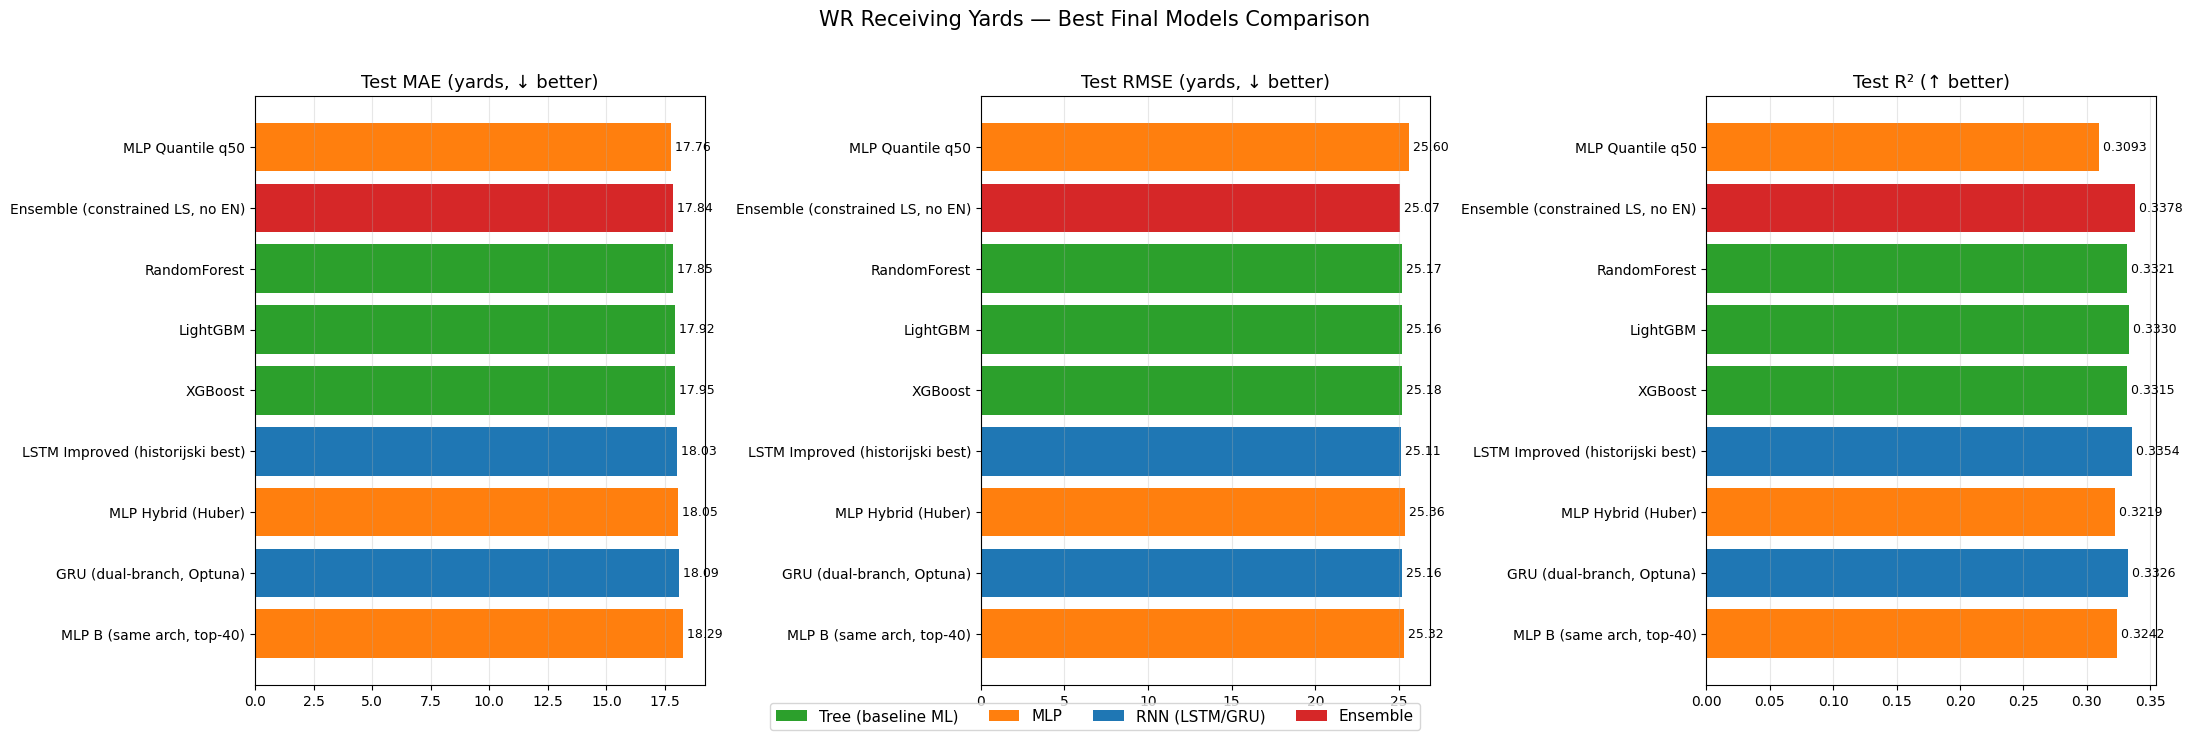

Saved: C:\Users\Korisnik\Documents\GitHub\Analiza-i-Obrada\results\wr_best_final_models_comparison.png


In [19]:
rows = []
for name, r in results.items():
    rows.append({
        'Model':     name,
        'Val MAE':   round(r['val']['MAE'],   3),
        'Val RMSE':  round(r['val']['RMSE'],  3),
        'Val R2':    round(r['val']['R2'],    4),
        'Test MAE':  round(r['test']['MAE'],  3),
        'Test RMSE': round(r['test']['RMSE'], 3),
        'Test R2':   round(r['test']['R2'],   4),
    })

summary = pd.DataFrame(rows).sort_values('Test MAE').reset_index(drop=True)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(RESULTS_DIR / 'wr_best_final_models_summary.csv', index=False)


type_color = {
    'RandomForest':                '#2ca02c',
    'XGBoost':                     '#2ca02c',
    'LightGBM':                    '#2ca02c',
    'MLP Hybrid (Huber)':          '#ff7f0e',
    'MLP B (same arch, top-40)':   '#ff7f0e',
    'MLP Quantile q50':            '#ff7f0e',
    'LSTM Improved (historijski best)':  '#1f77b4',
    'GRU (dual-branch, Optuna)':   '#1f77b4',
    'Ensemble (constrained LS, no EN)': '#d62728',
}

plot_df = summary.set_index('Model')
colors = [type_color.get(m, 'gray') for m in plot_df.index]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, metric, title in zip(
    axes,
    ['Test MAE', 'Test RMSE', 'Test R2'],
    ['Test MAE (yards, ↓ better)',
     'Test RMSE (yards, ↓ better)',
     'Test R² (↑ better)'],
):
    vals = plot_df[metric].values
    bars = ax.barh(plot_df.index, vals, color=colors)
    ax.set_title(title, fontsize=13)
    ax.invert_yaxis()
    fmt = '.2f' if 'R2' not in metric else '.4f'
    for i, v in enumerate(vals):
        ax.text(v, i, f' {v:{fmt}}', va='center', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', label='Tree (baseline ML)'),
    Patch(facecolor='#ff7f0e', label='MLP'),
    Patch(facecolor='#1f77b4', label='RNN (LSTM/GRU)'),
    Patch(facecolor='#d62728', label='Ensemble'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('WR Receiving Yards — Best Final Models Comparison',
             fontsize=15, y=1.02)
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / 'wr_best_final_models_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "wr_best_final_models_comparison.png"}')

### Tabela


In [20]:
print('=' * 95)
print('RANKING — BY TEST MAE (lower is better)')
print('=' * 95)
ranked = summary.copy()
ranked.insert(0, 'Rank', range(1, len(ranked) + 1))
print(ranked.to_string(index=False))

print()


# Save a final JSON with all metrics
final_output = {
    'config': {
        'seed': SEED,
        'train_seasons': train_seasons,
        'val_seasons':   val_seasons,
        'test_seasons':  test_seasons,
        'n_tabular_features': X_train.shape[1],
        'n_seq_features': n_seq_features,
        'n_static_features': n_static_features,
        'seq_len': SEQ_LEN,
    },
    'results': {
        name: {
            'val': r['val'],
            'test': r['test'],
            'seconds': r['seconds'],
        }
        for name, r in results.items()
    },
    'ensemble_weights': dict(zip(tabular_members, w_cls.tolist())),
}
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / 'wr_best_final_models_results.json', 'w') as f:
    json.dump(final_output, f, indent=2)
print(f'Saved: {RESULTS_DIR / "wr_best_final_models_results.json"}')

RANKING — BY TEST MAE (lower is better)
 Rank                            Model  Val MAE  Val RMSE  Val R2  Test MAE  Test RMSE  Test R2
    1                 MLP Quantile q50   17.954    26.006  0.3183    17.758     25.600   0.3093
    2 Ensemble (constrained LS, no EN)   18.055    25.445  0.3474    17.837     25.065   0.3378
    3                     RandomForest   18.129    25.543  0.3424    17.853     25.172   0.3321
    4                         LightGBM   18.114    25.539  0.3426    17.921     25.155   0.3330
    5                          XGBoost   18.104    25.535  0.3427    17.945     25.185   0.3315
    6 LSTM Improved (historijski best)   18.205    25.437  0.3478    18.029     25.110   0.3354
    7               MLP Hybrid (Huber)   18.269    25.790  0.3296    18.046     25.365   0.3219
    8        GRU (dual-branch, Optuna)   18.254    25.424  0.3484    18.094     25.164   0.3326
    9        MLP B (same arch, top-40)   18.566    25.762  0.3310    18.288     25.321   0.3242
